In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/train.csv")
df["LogSalePrice"] = np.log(df["SalePrice"])

## Stage 3 — Statistical Inference

In this stage, I compare house prices between groups to understand differences in the data.
The goal is to use simple hypothesis testing and careful interpretation.

I use `LogSalePrice` because it reduces the effect of extreme high prices.

### Comparing Prices: Central Air Conditioning

Research question:  
Do houses with central air conditioning sell for more than houses without central air conditioning?

In [2]:
with_air = df[df["CentralAir"] == "Y"]["LogSalePrice"]
without_air = df[df["CentralAir"] == "N"]["LogSalePrice"]

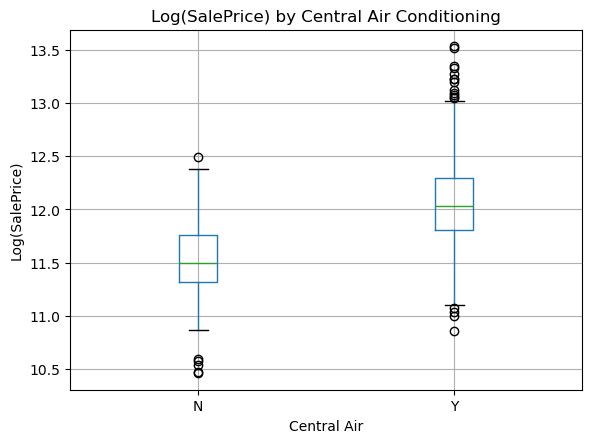

In [3]:
df.boxplot(column="LogSalePrice", by="CentralAir")
plt.title("Log(SalePrice) by Central Air Conditioning")
plt.suptitle("")
plt.xlabel("Central Air")
plt.ylabel("Log(SalePrice)")
plt.show()

### Interpretation (Boxplot)

The boxplot shows a clear difference between houses with and without central air conditioning.  
Houses with central air tend to have higher log-transformed sale prices.

There is still variability inside each group, so central air is not the only factor affecting prices.

### Hypotheses

- **Null hypothesis (H₀):**  
  There is no difference in average house prices between houses with and without central air conditioning.

- **Alternative hypothesis (H₁):**  
  There is a difference in average house prices between houses with and without central air conditioning.

In [4]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(with_air, without_air, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 13.774744264060383
p-value: 2.1965673234250233e-25


### Interpretation (t-test)

The p-value is extremely small (much smaller than 0.05).  
This suggests that the difference in average prices between the two groups is unlikely to be due to random chance.

So, we reject the null hypothesis and conclude that there is a statistically significant difference.

Important note: this does not prove that central air *causes* higher prices.  
Other factors like size, quality, and location also affect prices.

### Conclusion of Stage 3

In this stage, statistical inference was used to compare house prices between two groups.
Central air conditioning was associated with higher house prices in this dataset.

This prepares the project for the next stage: linear regression.